In [2]:
# Goal: Understand the data (How many matches ?, Missing Values?, Data Types?, Weird Values?)
import pandas as pd

path = "../data/raw/Fifa_world_cup_matches.csv"

df = pd.read_csv(path)

df.head()

# Detemine the winner of each game
def determine_result(row):
    if row['number of goals team1'] > row['number of goals team2']:
        return "Win"
    elif row['number of goals team1'] < row['number of goals team2']:
        return "Loss"
    else:
        return "Draw"
        
df['team1_result'] = df.apply(determine_result, axis=1)

In [3]:
# Clean percents out of possesion and convert to int
df['possession team1'] = df['possession team1'].str.replace('%', '').astype(int)
df['possession team2'] = df['possession team2'].str.replace('%', '').astype(int)

df[['possession team1', 'possession team2']].head()

,possession team1,possession team2
0,42,50
1,72,19
2,44,45
3,51,39
4,64,24


In [4]:
# Does having more possession mean you are more likely to win ? 
df.groupby('team1_result')['possession team1'].mean()

""" 
This output shows that in the 2022 World Cup teams on average
had a better chance of winning when they had less possession of 
the ball. This would signify that a counter attack appraoch 
was more effective during the tournament
"""

' \nThis output shows that in the 2022 World Cup teams on average\nhad a better chance of winning when they had less possession of \nthe ball. This would signify that a counter attack appraoch \nwas more effective during the tournament\n'

In [5]:
# Other important stats to check their influence on winning
stats_to_check = [
    'on target attempts team1',
    'total attempts team1',
    'defensive pressures applied team1'
]

df.groupby('team1_result')[stats_to_check].mean()

"""
This output shows more important stats that actually contribute to
a teams success. While total attempts goes up slightly, on target
attempts jumps massively and shows that accuracy is more meaningful
than just shooting blindly. We also see that applying defensive
pressure often contributes to their a won or drawn game.

Based on this data advice to provide a coach would be the following:

Don't worry about ball possession. Focus on high-intensity defensive 
pressing to win the ball, and make sure your shots are actually on 
target rather than just shooting from anywhere.
"""

"\nThis output shows more important stats that actually contribute to\na teams success. While total attempts goes up slightly, on target\nattempts jumps massively and shows that accuracy is more meaningful\nthan just shooting blindly. We also see that applying defensive\npressure often contributes to their a won or drawn game.\n\nBased on this data advice to provide a coach would be the following:\n\nDon't worry about ball possession. Focus on high-intensity defensive \npressing to win the ball, and make sure your shots are actually on \ntarget rather than just shooting from anywhere.\n"

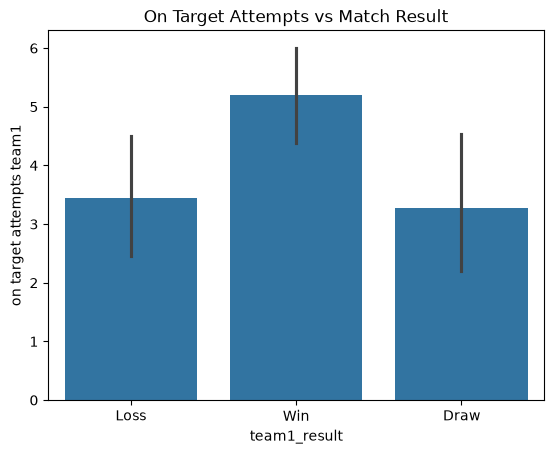

In [6]:
# Graphing the prototype results to futher see this impact
import seaborn as sns
import matplotlib.pyplot as plt

# Bar Plot for on target attempts
sns.barplot(data=df, x='team1_result', y='on target attempts team1')

plt.title("On Target Attempts vs Match Result")
plt.show()

In [7]:
# Save cleaned df to csv for future use in other notebooks
df.to_csv('../data/processed/cleaned_world_cup_matches.csv', index=False)